# 02 - Data Quality Analysis
* Identify missing data, duplicate records, incorrect data types, and unusual values.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
sellers = pd.read_csv('../data/raw/olist_sellers_dataset.csv')


## 1. Missing values
* Check the datasets for any empty or null values.

In [3]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [4]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [5]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

## What this indicates:

* Missing delivery dates may represent cancelled or pending orders.
* Missing review text means the customer did not provide a comment.



## 2. Duplicates
* Check the datasets for repeated or duplicate entries.

In [6]:
print('customers duplicates:', customers.duplicated().sum())
print('orders duplicates:', orders.duplicated().sum())
print('order_items duplicates:', order_items.duplicated().sum())
print('payments duplicates:', payments.duplicated().sum())
print('reviews duplicates:', reviews.duplicated().sum())
print('products duplicates:', products.duplicated().sum())
print('sellers duplicates:', sellers.duplicated().sum())


customers duplicates: 0
orders duplicates: 0
order_items duplicates: 0
payments duplicates: 0
reviews duplicates: 0
products duplicates: 0
sellers duplicates: 0


In [ ]:
#  check for orders with more than one review
print('orders with more than one review:', reviews['order_id'].duplicated().sum())


orders with more than one review: 551


## 3. Data type issues
* Identify columns with incorrect or inconsistent data types.

In [8]:
print(orders[['order_purchase_timestamp', 'order_delivered_customer_date']].dtypes)
# these should be dates, not text (object)


order_purchase_timestamp         object
order_delivered_customer_date    object
dtype: object


## 4. Outliers
* Check for unusually high or low values in the data.

In [9]:
order_items[['price', 'freight_value']].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


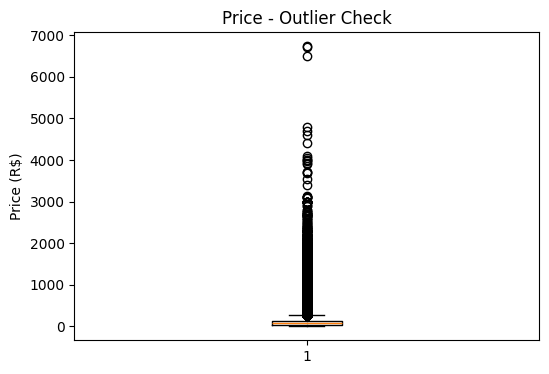

In [11]:
plt.figure(figsize=(6, 4))
plt.boxplot(order_items['price'])
plt.title('Price - Outlier Check')
plt.ylabel('Price (R$)')
plt.savefig('../figures/02_price_outliers.png')
plt.show()


**What this indicates:** A few high-value orders increase the price range, which is normal for a marketplace with different types of products and is not a data issue.


## Cleaning Steps for Notebook 03

* Convert text-based date columns into datetime format.
* Remove duplicate records.
* Replace missing product categories with 'unknown'.
* Convert product category names into English.
